In [1]:
import destruction_models as models
from tensorflow.keras import callbacks, metrics
from tensorflow.keras.utils import Sequence
from destruction_utilities import *
import matplotlib.pyplot as plt
import tensorflow as tf
import time
import pickle
from tensorflow.keras.models import load_model
from sklearn.metrics import precision_recall_curve, roc_auc_score, precision_score, recall_score

from tensorflow.keras.metrics import CategoricalAccuracy, Precision, AUC


In [2]:
CITY = 'test'
BATCH_SIZE = 32
TILE_SIZE = [128,128]

auc = AUC(
    num_thresholds=200,
    curve='ROC',
    name="auc"
)

Metal device set to: Apple M1

systemMemory: 16.00 GB
maxCacheSize: 5.33 GB



2022-07-29 17:53:21.901505: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2022-07-29 17:53:21.901624: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [3]:

class SiameseGenerator(Sequence):
    def __init__(self, images, labels, batch_size=BATCH_SIZE):
        self.images_t0 = images[0]
        self.images_tt = images[1]
        self.labels = labels
        self.batch_size = batch_size
        
        self.tuple_pairs = make_tuple_pair(self.images_t0.shape[0], int(self.batch_size/4))
        np.random.shuffle(self.tuple_pairs)
   
   
    def __len__(self):
        return len(self.images_t0)//self.batch_size
    
    
    
    def __getitem__(self, index):
        return self.get_sub_batch(index)

    def get_sub_batch(self,index):
        pos = index*4
        
        t, h, w, d = self.images_t0.shape
        X_t0_main = np.empty((0, h, w,d))
        X_tt_main = np.empty((0, h, w,d))
        y_main = np.empty(0)
#         X_t0_main = np.empty(0, h, w,d)
        for i in range(0,4):
            index_range = self.tuple_pairs[index+i]
            X_t0 = self.images_t0[index_range[0]:index_range[1]]
            X_tt = self.images_tt[index_range[0]:index_range[1]]
            y = self.labels[index_range[0]:index_range[1]]
            
            X_t0_main=np.append(X_t0_main, X_t0, axis=0)
            X_tt_main=np.append(X_tt_main, X_tt, axis=0)
            y_main=np.append(y_main, y, axis=0)
            alpha = random.choice(np.linspace(0.9, 1.1))
            
        indices = np.arange(0,self.batch_size)
        np.random.shuffle(indices)

        return {'images_t0':(X_t0_main *alpha)[indices], 'images_tt':(X_tt_main *alpha)[indices]}, y_main[indices]
        
    def augment(self, X):
#         # Horizontal and vertical flip
#         flipping_funcs = [
#             lambda image: image,
#             lambda image: np.fliplr(image),
#             lambda image: np.flipud(image),
#             lambda image: np.flipud(np.fliplr(image))
#         ]
#         func = random.choice(flipping_funcs)
#         X = func(X)
        
        # Brightness
        alpha = random.choice(np.linspace(0.85, 1.4))
#         alpha = 1
        X = X * alpha

        return X

In [4]:
def run_model(train_images, train_labels, valid_images, valid_labels, run_id = 1):
    train_gen = SiameseGenerator((train_images[0], train_images[1]), train_labels)
    valid_gen = SiameseGenerator((valid_images[0], valid_images[1]), valid_labels)
    
    training_callbacks = [
        callbacks.EarlyStopping(monitor='val_auc', patience=8, restore_best_weights=True),
        callbacks.ModelCheckpoint(f'../models/{CITY}/snn/run_{i}/', monitor='val_auc', verbose=0, save_best_only=True, save_weights_only=False, mode='max')
    ]
    
    filters = random.choice([32])
    dropout = random.choice(np.linspace(0.1, 0.15))
    epochs = random.choice(np.arange(70,100))
    units = random.choice([64])
    lr = random.choice([0.002, 0.003, 0.004])

    args_encode  = dict(filters=filters, dropout=dropout) # ! Check parameters before run
    args_dense  = dict(units=units) # ! Check parameters before run

    parameters = f'filters={filters}, \ndropout={np.round(dropout, 4)}, \nepochs={epochs}, \nunits={units}, \nlearning_rate={lr}'
    print(parameters)
    
#     model = models.siamese_convolutional_network(shape=(*TILE_SIZE, 3), args_encode=args_encode, args_dense=args_dense)
    model = models.siamese_convolutional_network(shape=(*TILE_SIZE, 3),  args_encode=dict(filters=filters, dropout=dropout), args_dense=dict(units=units, dropout=dropout))
   
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy',metrics.AUC(num_thresholds=200, curve='ROC', name='auc')])
    model.summary()
    

    # Train model on dataset
    history = model.fit(
        train_gen,
        validation_data=valid_gen,
        epochs=epochs,
        verbose=1,
        callbacks=training_callbacks
    )
    
    return model, history, parameters

In [5]:
def run_model_dist(train_images, train_labels, valid_images, valid_labels, run_id = 1):
    train_gen = SiameseGenerator((train_images[0], train_images[1]), train_labels)
    valid_gen = SiameseGenerator((valid_images[0], valid_images[1]), valid_labels)
    
    training_callbacks = [
        callbacks.EarlyStopping(monitor='val_auc', patience=8, restore_best_weights=True),
        callbacks.ModelCheckpoint(f'../models/{CITY}/snn_alt1/run_{i}/', monitor='val_auc', verbose=0, save_best_only=True, save_weights_only=False, mode='max')
    ]
    
    filters = random.choice([32])
    dropout = random.choice(np.linspace(0.1, 0.15))
    epochs = random.choice(np.arange(70,100))
    units = random.choice([64])
    lr = random.choice([0.002, 0.004, 0.006])

    args  = dict(filters=filters, dropout=dropout, units=units) # ! Check parameters before run

    parameters = f'filters={filters}, \ndropout={np.round(dropout, 4)}, \nepochs={epochs}, \nunits={units}, \nlearning_rate={lr}'
    print(parameters)
    
#     model = models.siamese_convolutional_network(shape=(*TILE_SIZE, 3), args_encode=args_encode, args_dense=args_dense)
    model = models.siamese_convolutional_network_dist(
        shape=(*TILE_SIZE, 3),  
        args = args,
    )
   
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    model.compile(optimizer=optimizer, loss='binary_focal_crossentropy', metrics=['accuracy',metrics.AUC(num_thresholds=200, curve='ROC', name='auc')])
    model.summary()
    

    # Train model on dataset
    history = model.fit(
        train_gen,
        validation_data=valid_gen,
        epochs=epochs,
        verbose=1,
        callbacks=training_callbacks
    )
    
    return model, history, parameters


In [6]:
train_images_t0 = read_zarr(CITY, 'images_siamese_train_t0_balanced')
train_images_tt = read_zarr(CITY, 'images_siamese_train_tt_balanced')
train_labels = read_zarr(CITY, 'labels_siamese_train_balanced')

valid_images_t0 = read_zarr(CITY, 'images_siamese_valid_t0')
valid_images_tt = read_zarr(CITY, 'images_siamese_valid_tt')
valid_labels = read_zarr(CITY, 'labels_siamese_valid')


test_images_t0 = read_zarr(CITY, 'images_siamese_test_t0')
test_images_tt = read_zarr(CITY, 'images_siamese_test_tt')
test_labels = read_zarr(CITY, 'labels_siamese_test')

train_gen = SiameseGenerator((train_images_t0, train_images_tt), train_labels)
valid_gen = SiameseGenerator((valid_images_t0, valid_images_tt), valid_labels)

In [7]:
def plot_training(H, P, ts, plotPath):
	# construct a plot that plots and saves the training history
	plt.style.use("ggplot")
	plt.figure()
	plt.plot(H.history["accuracy"], label="train_accuracy")
	plt.plot(H.history["val_accuracy"], label="val_accuracy")
	plt.plot(H.history["auc"], label="train_auc")
	plt.plot(H.history["val_auc"], label="val_auc")
	plt.title(f"Training Accuracy and AUC")
	plt.suptitle(f"City = {CITY}") 
	plt.xlabel("Epoch #")
	plt.ylabel("AUC")
	plt.text(0.65, 0.18, P + f"\nmax(val_auc)={np.round(np.max(H.history['val_auc']), 4)}\ncode={ts}", fontsize=8, transform=plt.gcf().transFigure)
	plt.legend(loc="lower left")
	plt.savefig(plotPath)

filters=32, 
dropout=0.1347, 
epochs=91, 
units=64, 
learning_rate=0.003
Model: "siamese_convolutional_network"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 images_t0 (InputLayer)         [(None, 128, 128, 3  0           []                               
                                )]                                                                
                                                                                                  
 images_tt (InputLayer)         [(None, 128, 128, 3  0           []                               
                                )]                                                                
                                                                                                  
 encoder (Functional)           (None, 2560)         371424      ['images_t0[0][0]',            

2022-07-29 17:53:22.179580: W tensorflow/core/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz
2022-07-29 17:53:23.036263: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


23/23 [==============================] - ETA: 0s - loss: 0.5403 - accuracy: 0.7622 - auc: 0.8323

2022-07-29 17:53:27.035085: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.
2022-07-29 17:53:28.172010: W tensorflow/python/util/util.cc:368] Sets are not currently considered sequences, but this may change in the future, so consider avoiding using them.


INFO:tensorflow:Assets written to: ../models/test/snn/run_0/assets
23/23 [==============================] - 8s 304ms/step - loss: 0.5403 - accuracy: 0.7622 - auc: 0.8323 - val_loss: 26.3379 - val_accuracy: 0.7875 - val_auc: 0.5000
Epoch 2/91
23/23 [==============================] - 3s 147ms/step - loss: 0.3021 - accuracy: 0.8886 - auc: 0.9479 - val_loss: 3.0256 - val_accuracy: 0.7375 - val_auc: 0.4392
Epoch 3/91
23/23 [==============================] - 6s 287ms/step - loss: 0.1765 - accuracy: 0.9348 - auc: 0.9809 - val_loss: 3.5036 - val_accuracy: 0.5437 - val_auc: 0.8095
Epoch 4/91
23/23 [==============================] - 3s 147ms/step - loss: 0.1139 - accuracy: 0.9620 - auc: 0.9917 - val_loss: 3.9830 - val_accuracy: 0.5125 - val_auc: 0.8091
Epoch 5/91
23/23 [==============================] - 6s 285ms/step - loss: 0.0961 - accuracy: 0.9660 - auc: 0.9926 - val_loss: 3.0361 - val_accuracy: 0.5375 - val_auc: 0.8294
Epoch 6/91
23/23 [==============================] - 7s 286ms/step - loss:

...

INFO:tensorflow:Assets written to: ../models/test/snn/run_3/assets
23/23 [==============================] - 10s 340ms/step - loss: 0.5534 - accuracy: 0.7432 - auc: 0.8079 - val_loss: 61.5134 - val_accuracy: 0.1187 - val_auc: 0.5000
Epoch 2/98
23/23 [==============================] - 4s 154ms/step - loss: 0.3013 - accuracy: 0.8791 - auc: 0.9300 - val_loss: 2.0492 - val_accuracy: 0.8000 - val_auc: 0.3830
Epoch 3/98
23/23 [==============================] - 8s 355ms/step - loss: 0.1581 - accuracy: 0.9470 - auc: 0.9799 - val_loss: 2.7378 - val_accuracy: 0.4313 - val_auc: 0.7736
Epoch 4/98
23/23 [==============================] - 4s 157ms/step - loss: 0.0868 - accuracy: 0.9688 - auc: 0.9958 - val_loss: 2.7147 - val_accuracy: 0.5563 - val_auc: 0.7725
Epoch 5/98
23/23 [==============================] - 8s 356ms/step - loss: 0.0632 - accuracy: 0.9823 - auc: 0.9962 - val_loss: 1.4860 - val_accuracy: 0.7875 - val_auc: 0.8882
Epoch 6/98
23/23 [==============================] - 4s 170ms/step - loss

2022-07-29 17:59:27.134578: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


23/23 [==============================] - ETA: 0s - loss: 0.5879 - accuracy: 0.7310 - auc: 0.7626

2022-07-29 17:59:32.162509: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


INFO:tensorflow:Assets written to: ../models/test/snn/run_4/assets
23/23 [==============================] - 11s 370ms/step - loss: 0.5879 - accuracy: 0.7310 - auc: 0.7626 - val_loss: 8.8390 - val_accuracy: 0.9187 - val_auc: 0.5000
Epoch 2/88
23/23 [==============================] - 4s 166ms/step - loss: 0.3141 - accuracy: 0.8940 - auc: 0.9031 - val_loss: 1.0900 - val_accuracy: 0.8000 - val_auc: 0.3744
Epoch 3/88
23/23 [==============================] - 5s 210ms/step - loss: 0.2187 - accuracy: 0.9307 - auc: 0.9515 - val_loss: 2.4340 - val_accuracy: 0.5813 - val_auc: 0.4126
Epoch 4/88
23/23 [==============================] - 8s 340ms/step - loss: 0.1617 - accuracy: 0.9321 - auc: 0.9775 - val_loss: 1.1040 - val_accuracy: 0.7438 - val_auc: 0.6355
Epoch 5/88
23/23 [==============================] - 4s 158ms/step - loss: 0.1224 - accuracy: 0.9620 - auc: 0.9856 - val_loss: 0.8130 - val_accuracy: 0.7625 - val_auc: 0.5811
Epoch 6/88
23/23 [==============================] - 8s 366ms/step - loss:

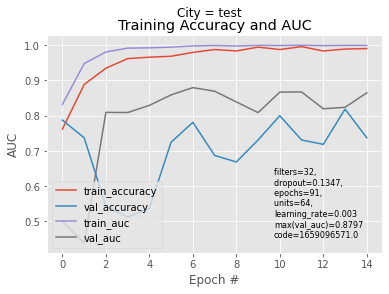

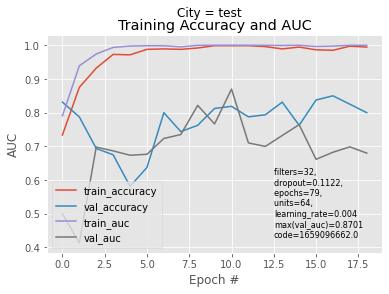

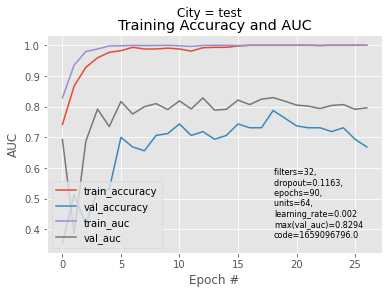

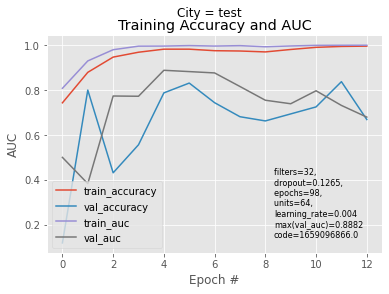

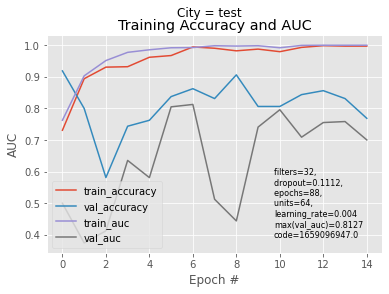

In [8]:
for i in range(0,5):
    m = run_model((train_images_t0, train_images_tt), train_labels, (valid_images_t0, valid_images_tt), valid_labels, run_id=i)
    model = m[0]
    history = m[1]
    parameters = m[2]
    print("Model optimization complete..\n\n")
    ts = str(np.round(time.time()))
    with open(f'../models/{CITY}_SNN_RUN{i}_{ts}_hist', 'wb') as file_pi:
        pickle.dump(history.history, file_pi)
    
    model.save(f'../models/{CITY}_SNN_RUN{i}_{ts}', save_format="h5")
    plot_training(history, parameters, ts, f'../figures/{CITY}_SNN_RUN{i}_{ts}.png')
    
    with open('../models/run_parameters.txt', "a") as file:
        file.write(f'{CITY}_SNN_RUN{i}_{ts}: \n \t{parameters}\n')
      


In [ ]:
# for i in range(0,5):
#     m = run_model_dist((train_images_t0, train_images_tt), train_labels, (valid_images_t0, valid_images_tt), valid_labels, run_id=i)
#     model = m[0]
#     history = m[1]
#     parameters = m[2]
#     print("Model optimization complete..\n\n")
#     ts = str(np.round(time.time()))
#     with open(f'../models/{CITY}_SNN_RUN{i}_{ts}_hist', 'wb') as file_pi:
#         pickle.dump(history.history, file_pi)
    
#     model.save(f'../models/{CITY}_SNN_RUN{i}_{ts}', save_format="h5")
#     plot_training(history, parameters, ts, f'../figures/{CITY}_SNN_RUN{i}_{ts}.png')
    
#     with open('../models/run_parameters.txt', "a") as file:
#         file.write(f'{CITY}_SNN_RUN{i}_{ts}: \n \t{parameters}\n')

In [11]:
class SiameseTestGenerator(Sequence):
    def __init__(self, images, batch_size=BATCH_SIZE):
        self.images_t0 = images[0]
        self.images_tt = images[1]
        self.batch_size = batch_size
        self.tuple_pairs = make_tuple_pair(self.images_t0.shape[0], self.batch_size)
        np.random.shuffle(self.tuple_pairs)

    def __len__(self):
        return len(self.images_t0)//self.batch_size
    
    def __getitem__(self, index):
        
#         index_range = self.tuple_pairs[index]
#         indices = np.arange(0,32)
#         np.random.shuffle(indices)

#         X_t0 = self.images_t0[index_range[0]:index_range[1]][indices]
#         X_t1 = self.images_tt[index_range[0]:index_range[1]][indices]
        
#         alpha = 1
        
#         return {'images_t0':X_t0 *alpha, 'images_tt':X_t1 *alpha}
        
        if(index == self.__len__()-1):
            X_t0 = self.images_t0[index*self.batch_size:len(self.images_t0)]
            X_tt = self.images_tt[index*self.batch_size:len(self.images_tt)]
        else:
            X_t0 = self.images_t0[index*self.batch_size:(index+1)*self.batch_size]          
            X_tt = self.images_tt[index*self.batch_size:(index+1)*self.batch_size]          
    
        
        return {'images_t0':X_t0, 'images_tt':X_tt}

2022-07-29 18:09:27.794114: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


Run 1 
Test Set AUC Score for the ROC Curve: 0.7690888119953864 
Average precision:  0.3940342073427135


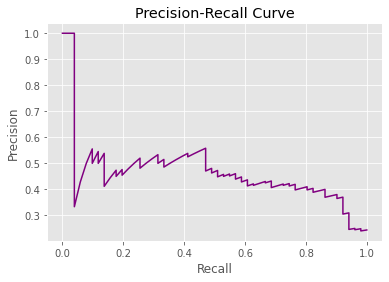

2022-07-29 18:09:31.297802: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


Run 2 
Test Set AUC Score for the ROC Curve: 0.7337946943483276 
Average precision:  0.39833232331580665


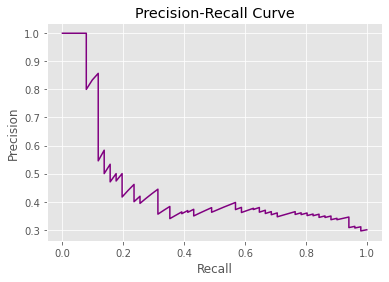

2022-07-29 18:09:35.050953: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


Run 3 
Test Set AUC Score for the ROC Curve: 0.7170703575547867 
Average precision:  0.35267226766645493


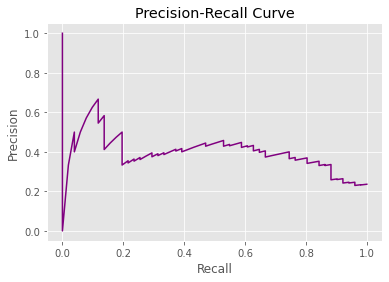

2022-07-29 18:09:38.296308: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


Run 4 
Test Set AUC Score for the ROC Curve: 0.7284313725490196 
Average precision:  0.3584090062094725


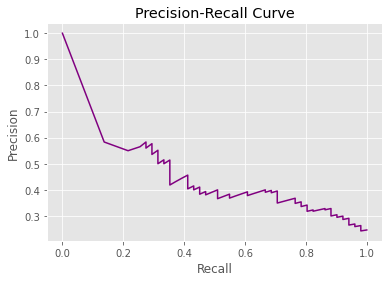

2022-07-29 18:09:41.828206: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


Run 5 
Test Set AUC Score for the ROC Curve: 0.6490196078431373 
Average precision:  0.325767342800288


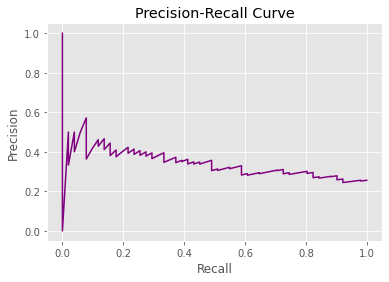

In [12]:
for i in range(0, 5):
    model_path = f'../models/{CITY}/snn/run_{i}'
    best_model = load_model(model_path, custom_objects={'auc':metrics.AUC(num_thresholds=200, curve='ROC', name='auc')})
    test_generator = SiameseTestGenerator((test_images_t0, test_images_tt))
    yhat_proba, y = np.squeeze(best_model.predict(test_generator)), np.squeeze(test_labels[:])
    roc_auc_test = roc_auc_score(y, yhat_proba)
    #calculate precision and recall
    precision, recall, thresholds = precision_recall_curve(y, yhat_proba)


    #create precision recall curve
    fig, ax = plt.subplots()
    ax.plot(recall, precision, color='purple')

    #add axis labels to plot
    ax.set_title('Precision-Recall Curve')
    ax.set_ylabel('Precision')
    ax.set_xlabel('Recall')

    print(f'Run {i+1} \nTest Set AUC Score for the ROC Curve: {roc_auc_test} \nAverage precision:  {np.mean(precision)}' )
    #display plot
    plt.show()

In [ ]:
# for i in range(0, 5):
#     model_path = f'../models/{CITY}/snn_alt1/run_{i}'
#     best_model = load_model(model_path, custom_objects={'auc':metrics.AUC(num_thresholds=200, curve='ROC', name='auc')})
#     test_generator = SiameseTestGenerator((test_images_t0, test_images_tt))
#     yhat_proba, y = np.squeeze(best_model.predict(test_generator)), np.squeeze(test_labels[:])
#     roc_auc_test = roc_auc_score(y, yhat_proba)
#     #calculate precision and recall
#     precision, recall, thresholds = precision_recall_curve(y, yhat_proba)


#     #create precision recall curve
#     fig, ax = plt.subplots()
#     ax.plot(recall, precision, color='purple')

#     #add axis labels to plot
#     ax.set_title('Precision-Recall Curve')
#     ax.set_ylabel('Precision')
#     ax.set_xlabel('Recall')

#     print(f'Run {i+1} \nTest Set AUC Score for the ROC Curve: {roc_auc_test} \nAverage precision:  {np.mean(precision)}' )
#     #display plot
#     plt.show()

```
filters=32, dropout=0.13163265306122449, epochs=77, units=32, learning_rate=0.01
filters=32, dropout=0.18571428571428572, epochs=88, units=48, learning_rate=0.003

Upto 88
filters=32, 
dropout=0.1939, 
epochs=77, 
units=32, 
learning_rate=0.012


```